In [14]:
import numpy as np
from scipy import stats
from scipy.interpolate import griddata

import einops
import concurrent.futures
import pickle


import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import niapy
from niapy.problems import Alpine1 as TestFunction

import hiposa
from hiposa.poisson_disc_sampling import PoissonDiskSamplerWithExisting

import os

In [16]:
obj = PoissonDiskSamplerWithExisting(domain=[(0,1),(0,1)], r=0.22, wrap=True )
xy, levels = obj.sample()

print(xy)

[[0.37148698 0.67206925]
 [0.65440337 0.71082969]
 [0.91071494 0.54990606]
 [0.88321044 0.13271876]
 [0.51506918 0.49044132]
 [0.18150869 0.87789395]
 [0.86326475 0.84616347]
 [0.18195393 0.45064712]
 [0.1410871  0.19568404]
 [0.4643603  0.14802202]
 [0.67661234 0.32437754]
 [0.5917048  0.95849162]
 [0.1000784  0.67154716]]


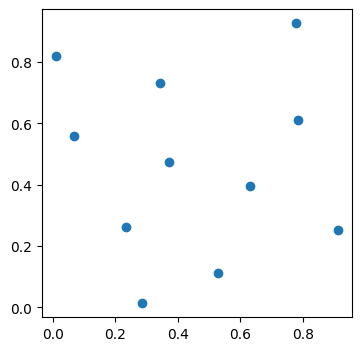

In [3]:
plt.figure(figsize=(4,4))
plt.scatter(xy[:,0], xy[:,1])
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define the original points from the example
original_points = xy

# Calculate minimum distance with periodic boundaries
def calc_min_distance(points, periodic=True, domain_size=1.0):
    """Calculate minimum pairwise distance with periodic boundaries."""
    n_points = len(points)
    min_dist = float('inf')
    min_pair = None
    
    for i in range(n_points):
        for j in range(i+1, n_points):
            # Get points
            p1 = points[i]
            p2 = points[j]
            
            if periodic:
                # Calculate distance with periodic boundaries
                delta = np.abs(p1 - p2)
                if isinstance(domain_size, (int, float)):
                    domain_size = np.array([domain_size, domain_size])
                wrapped_delta = domain_size - delta
                min_delta = np.minimum(delta, wrapped_delta)
                dist = np.sqrt(np.sum(min_delta**2))
            else:
                # Calculate direct Euclidean distance
                dist = np.sqrt(np.sum((p1 - p2)**2))
            
            if dist < min_dist:
                min_dist = dist
                min_pair = (i, j)
    
    return min_dist, min_pair

# Compute original min distance r
r, min_orig_pair = calc_min_distance(original_points)
r_half = r / 2.0  # r/2 threshold
print(f"Original minimum distance (r): {r:.6f}")
print(f"Between points {min_orig_pair[0]} and {min_orig_pair[1]}")
print(f"Target r/2 distance: {r_half:.6f}")

# Parameters
epsilon = 1e-2  # Threshold for considering points as duplicates

# Define tiling offsets for checking all possible tilings
tiling_offsets = np.array([
    [0.0, 0.0], [0.5, 0.0], [0.0, 0.5], [0.5, 0.5],
    [-0.5, 0.0], [0.0, -0.5], [-0.5, -0.5],
    [0.5, -0.5], [-0.5, 0.5]
])

# Initialize scaled points - just divide original by 2 and wrap to [0, 0.5]
scaled_points_initial = original_points / 2.0 % 0.5

# Function to check distance constraints between original and scaled points
def check_distance_constraints(original_points, scaled_points, r_half, epsilon, tiling_offsets):
    """
    Check distance constraints between original and scaled points.
    Return number of violations and list of violations.
    """
    violations = []
    
    for i in range(len(original_points)):
        for j in range(len(scaled_points)):
            closest_dist = float('inf')
            closest_offset = None
            
            # Check all possible tilings
            for offset in tiling_offsets:
                tiled_point = scaled_points[j] + offset
                dist = np.sqrt(np.sum((original_points[i] - tiled_point)**2))
                
                if dist < closest_dist:
                    closest_dist = dist
                    closest_offset = offset
            
            # Check if violates our constraint (neither close enough to be same nor far enough apart)
            if epsilon < closest_dist < r_half:
                violations.append({
                    'orig_idx': i, 
                    'scaled_idx': j, 
                    'offset': closest_offset, 
                    'distance': closest_dist
                })
    
    return len(violations), violations

# Calculate penalty for a given configuration
def calculate_penalty(scaled_points, original_points, r_half, epsilon, tiling_offsets, scale_inv_weight=0.1):
    """
    Calculate penalty for a given configuration of scaled points.
    
    Parameters:
    - scaled_points: Array of scaled points in [0, 0.5] domain
    - original_points: Array of original points in [0, 1] domain
    - r_half: Target minimum distance / 2
    - epsilon: Threshold for considering points as duplicates
    - tiling_offsets: Array of tiling offsets to check
    - scale_inv_weight: Weight for scale-invariance penalty (0 = ignore scale invariance)
    
    Returns:
    - total_penalty: Sum of all penalties
    - min_dist: Minimum distance between scaled points
    - num_violations: Number of distance constraint violations
    """
    # Ensure all points are in [0, 0.5] range
    working_points = scaled_points.copy() % 0.5
    
    # 1. Penalize distances between scaled points that are too close
    min_dist = float('inf')
    scaled_dist_penalty = 0.0
    
    for i in range(len(working_points)):
        for j in range(i+1, len(working_points)):
            # Calculate minimum distance with periodic boundaries in [0, 0.5] domain
            delta = np.abs(working_points[i] - working_points[j])
            wrapped_delta = 0.5 - delta
            min_delta = np.minimum(delta, wrapped_delta)
            dist = np.sqrt(np.sum(min_delta**2))
            
            min_dist = min(min_dist, dist)
            
            # If distance is less than r/2, add penalty
            if dist < r_half:
                penalty = (dist - r_half)**2
                scaled_dist_penalty += penalty
    
    # 2. Penalize distance constraint violations
    violation_penalty = 0.0
    num_violations, violations = check_distance_constraints(
        original_points, working_points, r_half, epsilon, tiling_offsets
    )
    
    for violation in violations:
        dist = violation['distance']
        # Quadratic penalty based on how far from either boundary
        dist_to_eps = dist - epsilon
        dist_to_r_half = r_half - dist
        penalty = min(dist_to_eps, dist_to_r_half)**2
        violation_penalty += penalty
    
    # 3. Optionally penalize deviation from scale invariance
    doubled_points = (working_points * 2) % 1
    scale_inv_penalty = 0.0
    
    if scale_inv_weight > 0:
        for i, doubled in enumerate(doubled_points):
            # Find closest original point
            min_dist_to_orig = float('inf')
            for j, orig in enumerate(original_points):
                # Calculate with periodic boundaries
                delta = np.abs(doubled - orig)
                wrapped_delta = 1.0 - delta
                min_delta = np.minimum(delta, wrapped_delta)
                dist = np.sqrt(np.sum(min_delta**2))
                
                min_dist_to_orig = min(min_dist_to_orig, dist)
            
            # Add penalty based on distance to closest original point
            scale_inv_penalty += min_dist_to_orig
    
    # Total penalty
    total_penalty = (
        scaled_dist_penalty * 10.0 +  # Heavily penalize scaled points too close to each other
        violation_penalty * 100.0 +   # Most important: fix distance constraint violations
        scale_inv_penalty * scale_inv_weight  # Optional: maintain scale invariance
    )
    
    return total_penalty, min_dist, num_violations

# Function to analyze results
def analyze_result(original_points, scaled_points, r, r_half, epsilon, tiling_offsets):
    """Analyze the result, checking all constraints."""
    # Check minimum distance between original points
    min_orig_dist, _ = calc_min_distance(original_points)
    
    # Check minimum distance between scaled points
    min_scaled_dist, _ = calc_min_distance(scaled_points, periodic=True, domain_size=0.5)
    
    # Check scale invariance
    doubled_points = (scaled_points * 2) % 1
    scale_matches = []
    
    for i, doubled in enumerate(doubled_points):
        for j, orig in enumerate(original_points):
            # Direct distance (non-periodic for clarity)
            dist = np.sqrt(np.sum((doubled - orig)**2))
            if dist < epsilon:
                scale_matches.append((i, j, dist))
    
    # Check distances between original and scaled points with tilings
    orig_to_scaled_dists = []
    violations = []
    duplicates = []
    valid_pairs = []
    
    for i in range(len(original_points)):
        for j in range(len(scaled_points)):
            closest_dist = float('inf')
            closest_offset = None
            
            # Check all possible tilings
            for offset in tiling_offsets:
                tiled_point = scaled_points[j] + offset
                dist = np.sqrt(np.sum((original_points[i] - tiled_point)**2))
                
                if dist < closest_dist:
                    closest_dist = dist
                    closest_offset = offset
            
            orig_to_scaled_dists.append(closest_dist)
            
            # Categorize based on distance
            if closest_dist < epsilon:
                duplicates.append((i, j, closest_offset, closest_dist))
            elif closest_dist < r_half:
                violations.append((i, j, closest_offset, closest_dist))
            else:
                valid_pairs.append((i, j, closest_offset, closest_dist))
    
    return {
        'min_orig_dist': min_orig_dist,
        'min_scaled_dist': min_scaled_dist,
        'min_orig_to_scaled': min(orig_to_scaled_dists) if orig_to_scaled_dists else float('inf'),
        'scale_matches': scale_matches,
        'violations': violations,
        'duplicates': duplicates,
        'valid_pairs': valid_pairs
    }

# Print initial analysis
initial_violations, _ = check_distance_constraints(
    original_points, scaled_points_initial, r_half, epsilon, tiling_offsets
)
print(f"\nInitial scaled points have {initial_violations} distance constraint violations")

# Implement simulated annealing for optimization
def simulated_annealing(initial_points, original_points, r_half, epsilon, tiling_offsets, 
                       n_iterations=10000, initial_temp=0.1, cooling_rate=0.99, 
                       scale_inv_weight=0.1):
    """
    Optimize using simulated annealing.
    Prioritizes fixing distance constraint violations over scale invariance.
    """
    current_points = initial_points.copy()
    best_points = current_points.copy()
    
    current_penalty, current_min_dist, current_violations = calculate_penalty(
        current_points, original_points, r_half, epsilon, tiling_offsets, scale_inv_weight
    )
    
    best_penalty = current_penalty
    best_violations = current_violations
    
    temp = initial_temp
    penalty_history = []
    violation_history = []
    min_dist_history = []
    
    # For each iteration
    print(f"\nStarting simulated annealing optimization (scale_inv_weight={scale_inv_weight})...")
    pbar = tqdm(range(n_iterations))
    for i in pbar:
        # Randomly select a point to perturb
        idx = np.random.randint(0, len(current_points))
        
        # Create a candidate solution with a small perturbation
        candidate = current_points.copy()
        perturbation = np.random.normal(0, temp, size=2) * 0.5  # Scale perturbation by domain size
        candidate[idx] += perturbation
        candidate[idx] = candidate[idx] % 0.5  # Ensure in [0, 0.5] domain
        
        # Calculate new penalty
        new_penalty, new_min_dist, new_violations = calculate_penalty(
            candidate, original_points, r_half, epsilon, tiling_offsets, scale_inv_weight
        )
        
        # Decide whether to accept the new solution
        delta_penalty = new_penalty - current_penalty
        
        if delta_penalty < 0 or np.random.random() < np.exp(-delta_penalty / temp):
            # Accept the new solution
            current_points = candidate
            current_penalty = new_penalty
            current_min_dist = new_min_dist
            current_violations = new_violations
            
            # Update best solution if this is better
            if new_penalty < best_penalty:
                best_penalty = new_penalty
                best_points = candidate.copy()
                best_violations = new_violations
        
        # Cool down the temperature
        temp *= cooling_rate
        
        # Record history
        penalty_history.append(current_penalty)
        violation_history.append(current_violations)
        min_dist_history.append(current_min_dist)
        
        # Update progress bar
        if i % 100 == 0:
            pbar.set_description(f"Penalty: {current_penalty:.6f}, Violations: {current_violations}, Min dist: {current_min_dist:.6f}")
        
        # Early stopping if we've found a solution with no violations
        if current_violations == 0 and current_min_dist >= r_half:
            print(f"\nFound solution with no violations at iteration {i}")
            break
    
    return best_points, penalty_history, violation_history, min_dist_history

# Optimize with decreasing weight on scale invariance
# Start with higher weight to try to preserve scale invariance while allowing more movement
optimized_points, penalty_history, violation_history, min_dist_history = simulated_annealing(
    scaled_points_initial, original_points, r_half, epsilon, tiling_offsets,
    n_iterations=10000, initial_temp=0.1, cooling_rate=0.99, scale_inv_weight=0.1
)

# If we still have violations, try again with less emphasis on scale invariance
final_violations, _ = check_distance_constraints(
    original_points, optimized_points, r_half, epsilon, tiling_offsets
)

if final_violations > 0:
    print(f"\nStill have {final_violations} violations. Trying with lower scale invariance weight...")
    optimized_points, penalty_history2, violation_history2, min_dist_history2 = simulated_annealing(
        optimized_points, original_points, r_half, epsilon, tiling_offsets,
        n_iterations=5000, initial_temp=0.05, cooling_rate=0.99, scale_inv_weight=0.01
    )
    
    # Append histories
    penalty_history.extend(penalty_history2)
    violation_history.extend(violation_history2)
    min_dist_history.extend(min_dist_history2)

# Create doubled points from optimized scaled points
doubled_points = (optimized_points * 2) % 1

# Analyze the optimized result
result = analyze_result(
    original_points, optimized_points, r, r_half, epsilon, tiling_offsets
)

print("\nAnalysis of optimized result:")
print(f"Original points min distance: {result['min_orig_dist']:.6f} (should be ≥ {r:.6f})")
print(f"Scaled points min distance: {result['min_scaled_dist']:.6f} (should be ≥ {r_half:.6f})")
print(f"Min distance between original and scaled points: {result['min_orig_to_scaled']:.6f}")
print(f"Number of violations: {len(result['violations'])}")
print(f"Number of duplicates: {len(result['duplicates'])}")
print(f"Number of valid pairs: {len(result['valid_pairs'])}")
print(f"Scale-invariant matches: {len(result['scale_matches'])}/{len(original_points)}")

# Print the optimized scaled points
print("\nOptimized scaled points:")
for i, point in enumerate(optimized_points):
    doubled = doubled_points[i]
    print(f"{i}: [{point[0]:.6f}, {point[1]:.6f}] -> doubled: [{doubled[0]:.6f}, {doubled[1]:.6f}]")

# Visualize the results
plt.figure(figsize=(15, 10))

# Plot penalty history
plt.subplot(2, 2, 1)
plt.plot(penalty_history)
plt.title('Penalty during optimization')
plt.xlabel('Iteration')
plt.ylabel('Penalty')
if min(penalty_history) > 0:
    plt.yscale('log')

# Plot violation history
plt.subplot(2, 2, 2)
plt.plot(violation_history)
plt.title('Number of violations during optimization')
plt.xlabel('Iteration')
plt.ylabel('Violations')

# Plot original and doubled points
plt.subplot(2, 2, 3)
plt.scatter(original_points[:, 0], original_points[:, 1], c='blue', label='Original')
plt.scatter(doubled_points[:, 0], doubled_points[:, 1], c='green', label='Doubled scaled')

# Connect scale-invariant matches
for i, j, _ in result['scale_matches']:
    plt.plot([doubled_points[i, 0], original_points[j, 0]], 
             [doubled_points[i, 1], original_points[j, 1]], 
             'g--', alpha=0.5)

plt.title(f'Original vs Doubled Points\nScale matches: {len(result["scale_matches"])}/{len(original_points)}')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

# Plot optimized scaled points
plt.subplot(2, 2, 4)
plt.scatter(optimized_points[:, 0], optimized_points[:, 1], c='red', label='Optimized scaled')
plt.title(f'Optimized Scaled Points (min dist = {result["min_scaled_dist"]:.4f})')
plt.xlim(0, 0.5)
plt.ylim(0, 0.5)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('distance_prioritized_results.png')
plt.close()

# Create a tiled visualization to check constraints
def plot_tiled_points(original_points, scaled_points, doubled_points, r, r_half, result, tiling_offsets):
    plt.figure(figsize=(12, 12))
    
    # Plot original points
    plt.scatter(original_points[:, 0], original_points[:, 1], c='blue', label='Original', s=80, alpha=0.7)
    
    # Plot doubled points
    plt.scatter(doubled_points[:, 0], doubled_points[:, 1], c='green', label='Doubled scaled', s=60, alpha=0.7)
    
    # Draw r/2 circles around original points
    for i, point in enumerate(original_points):
        circle = plt.Circle((point[0], point[1]), r_half, fill=False, color='green', alpha=0.5)
        plt.gca().add_patch(circle)
    
    # Plot scaled points with all relevant tilings
    for offset in tiling_offsets:
        tiled_points = scaled_points + offset
        
        # Only plot if some points fall in the extended plotting region
        if np.any((tiled_points[:, 0] > -0.6) & (tiled_points[:, 0] < 1.6) & 
                  (tiled_points[:, 1] > -0.6) & (tiled_points[:, 1] < 1.6)):
            plt.scatter(tiled_points[:, 0], tiled_points[:, 1], c='red', s=40, alpha=0.5, marker='x')
    
    # Highlight duplicates in green
    for i, j, offset, dist in result['duplicates']:
        tiled_point = scaled_points[j] + offset
        plt.plot([original_points[i, 0], tiled_point[0]], 
                 [original_points[i, 1], tiled_point[1]], 
                 'g-', alpha=0.8, linewidth=2)
        
    # Highlight violations in red
    for i, j, offset, dist in result['violations']:
        tiled_point = scaled_points[j] + offset
        plt.plot([original_points[i, 0], tiled_point[0]], 
                 [original_points[i, 1], tiled_point[1]], 
                 'r-', alpha=0.8, linewidth=2)
        
    # Connect doubled points to original points to show scale invariance
    for i, j, dist in result['scale_matches']:
        plt.plot([doubled_points[i, 0], original_points[j, 0]], 
                 [doubled_points[i, 1], original_points[j, 1]], 
                 'c--', alpha=0.8, linewidth=1.5)
    
    # Set plot limits to show both original and relevant tiled points
    plt.xlim(-0.6, 1.6)
    plt.ylim(-0.6, 1.6)
    plt.grid(True)
    plt.title(f'Distance-Prioritized Tiling Visualization\n'
              f'Original min dist: {r:.4f}, Target: {r_half:.4f}\n'
              f'Violations: {len(result["violations"])}, Scale-invariant matches: {len(result["scale_matches"])}')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Original points'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Doubled scaled points'),
        Line2D([0], [0], marker='x', color='red', markersize=10, label='Scaled points (tiled)'),
        Line2D([0], [0], color='g', linewidth=2, label='Duplicates (d < ε)'),
        Line2D([0], [0], color='r', linewidth=2, label='Violations (ε < d < r/2)'),
        Line2D([0], [0], color='c', linestyle='--', linewidth=2, label='Scale-invariant matches')
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.savefig('distance_prioritized_tiling_visualization.png')
    plt.close()

# Create the tiled visualization
plot_tiled_points(
    original_points,
    optimized_points,
    doubled_points,
    r,
    r_half,
    result,
    tiling_offsets
)

print("\nOptimization complete. Visualizations saved as:")
print("- distance_prioritized_results.png")
print("- distance_prioritized_tiling_visualization.png")

Original minimum distance (r): 0.221833
Between points 5 and 12
Target r/2 distance: 0.110917

Initial scaled points have 20 distance constraint violations

Starting simulated annealing optimization (scale_inv_weight=0.1)...


Penalty: 0.601509, Violations: 14, Min dist: 0.033592: 100%|███████████████████████████████████| 10000/10000 [00:47<00:00, 211.17it/s]



Still have 14 violations. Trying with lower scale invariance weight...

Starting simulated annealing optimization (scale_inv_weight=0.01)...


Penalty: 0.412215, Violations: 13, Min dist: 0.035997: 100%|█████████████████████████████████████| 5000/5000 [00:23<00:00, 208.78it/s]



Analysis of optimized result:
Original points min distance: 0.221833 (should be ≥ 0.221833)
Scaled points min distance: 0.035997 (should be ≥ 0.110917)
Min distance between original and scaled points: 0.009249
Number of violations: 13
Number of duplicates: 1
Number of valid pairs: 155
Scale-invariant matches: 0/13

Optimized scaled points:
0: [0.057767, 0.352863] -> doubled: [0.115535, 0.705726]
1: [0.352192, 0.456889] -> doubled: [0.704385, 0.913778]
2: [0.473209, 0.258178] -> doubled: [0.946418, 0.516357]
3: [0.452225, 0.411465] -> doubled: [0.904450, 0.822930]
4: [0.285224, 0.265478] -> doubled: [0.570447, 0.530957]
5: [0.086375, 0.431270] -> doubled: [0.172749, 0.862541]
6: [0.355924, 0.340537] -> doubled: [0.711847, 0.681074]
7: [0.003643, 0.238955] -> doubled: [0.007286, 0.477909]
8: [0.147683, 0.056428] -> doubled: [0.295367, 0.112856]
9: [0.290387, 0.027210] -> doubled: [0.580775, 0.054420]
10: [0.360719, 0.209892] -> doubled: [0.721437, 0.419783]
11: [0.280967, 0.102636] -> d

[[0.04282149 0.01662933]
 [0.45723219 0.43656636]
 [0.10731558 0.20919007]
 [0.37218551 0.44220977]
 [0.44961359 0.21917264]
 [0.34183899 0.1248187 ]
 [0.15475767 0.05349887]
 [0.19755095 0.42575138]
 [0.3755671  0.32183563]
 [0.47277452 0.08988618]]


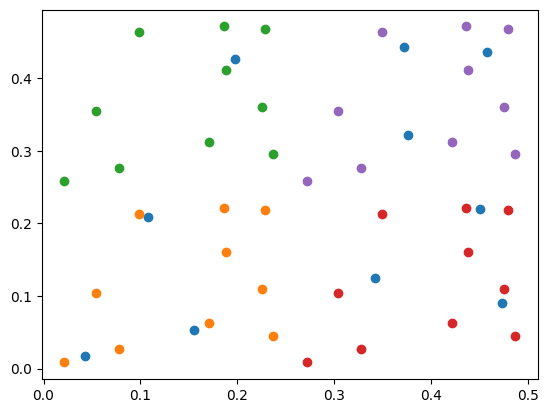

In [13]:
print(optimized_points)
plt.scatter(optimized_points[:,0], optimized_points[:,1])
plt.scatter(optimized_points[:,0]/2, optimized_points[:,1]/2)
plt.scatter(optimized_points[:,0]/2, optimized_points[:,1]/2+0.25)
plt.scatter(optimized_points[:,0]/2+0.25, optimized_points[:,1]/2)
plt.scatter(optimized_points[:,0]/2+0.25, optimized_points[:,1]/2+0.25)


In [9]:
print(optimized_points)

[[0.35838821 0.43701522]
 [0.14883806 0.4403709 ]
 [0.00533691 0.2249775 ]
 [0.47050146 0.46592613]
 [0.37863873 0.32493293]
 [0.1060211  0.16858782]
 [0.05496136 0.02161325]
 [0.27696718 0.02414206]
 [0.19704243 0.30978047]
 [0.47199392 0.09242444]]
